# **ANALISIS SENTIMEN AVETA**

**Import Library**

In [1]:
!pip install Sastrawi

  Using cached Sastrawi-1.0.1-py2.py3-none-any.whl.metadata (909 bytes)
Using cached Sastrawi-1.0.1-py2.py3-none-any.whl (209 kB)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Model Librari
import pandas as pd
import re
import nltk
import string
import requests
import ast
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

Import Data

In [ ]:
data = pd.read_csv('hasil_labeling_transformer_aveta.csv')
data = data.loc[:, ~data.columns.str.contains("^Unnamed")]
print(f"Total data: {len(data)}")
data.head()

Total data: 2449


,rating,ulasan,label
0,5/5,Hotel yang sgt strategis di jalan malioboro. K...,Negatif
1,5/5,Lokasi yang top. Di sekitar lokasi hotel banya...,Positif
2,2/5,Kurang saya rekomendasikan. Pesan premier room...,Negatif
3,5/5,nginap 2 hari dan 2 malam bersama istri dan an...,Positif
4,2/5,Saya memberikan bintang 2 ini sebelum saya mas...,Negatif


**Distribusi Data**

In [ ]:
jumlah = data['label'].value_counts(dropna=False)
persen = data['label'].value_counts(dropna=False, normalize=True) * 100
hasil = pd.DataFrame({
    'Jumlah': jumlah,
    'Persentase (%)': persen.round(2)
})
print(hasil)

         Jumlah  Persentase (%)
label                          
Positif    2242           91.55
Negatif     188            7.68
NaN          19            0.78


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2449 entries, 0 to 2448
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   rating  2449 non-null   object
 1   ulasan  2449 non-null   object
 2   label   2430 non-null   object
dtypes: object(3)
memory usage: 57.5+ KB


In [ ]:
data.describe()

,rating,ulasan,label
count,2449,2449,2430
unique,7,2366,2
top,5/5,Bagus,Positif
freq,1853,20,2242


In [ ]:
# Missing Value
data = data.dropna()
data.isnull().sum()

,0
rating,0
ulasan,0
label,0


**Cek Data Unlabeled**

In [ ]:
persentase = data['label'].isna().mean() * 100
print(f"Persentase data tanpa label: {persentase:.2f}%")

Persentase data tanpa label: 0.00%


In [ ]:
total = len(data)
kosong = data['label'].isna().sum()
print(f"Total data       : {total}")
print(f"Tanpa label      : {kosong}")
print(f"Persentase (%)   : {kosong/total*100:.2f}%")

Total data       : 2430
Tanpa label      : 0
Persentase (%)   : 0.00%


In [ ]:
data = data.dropna(subset=['label']) #drop data unlabeled

In [ ]:
# data.to_csv('2label aveta.csv', index=False)

Setelah Melakukan Drop Data Nan

In [ ]:
data = pd.read_csv('dua_label_aveta.csv')
data = data.loc[:, ~data.columns.str.contains("^Unnamed")]
print(f"Total data: {len(data)}")
data.head()

Total data: 2430


,rating,ulasan,label
0,5/5,Hotel yang sgt strategis di jalan malioboro. K...,Negatif
1,5/5,Lokasi yang top. Di sekitar lokasi hotel banya...,Positif
2,2/5,Kurang saya rekomendasikan. Pesan premier room...,Negatif
3,5/5,nginap 2 hari dan 2 malam bersama istri dan an...,Positif
4,2/5,Saya memberikan bintang 2 ini sebelum saya mas...,Negatif


In [ ]:
jumlah = data['label'].value_counts(dropna=False)
persen = data['label'].value_counts(dropna=False, normalize=True) * 100
hasil = pd.DataFrame({
    'Jumlah': jumlah,
    'Persentase (%)': persen.round(2)
})
print(hasil)

         Jumlah  Persentase (%)
label                          
Positif    2242           92.26
Negatif     188            7.74


In [ ]:
total_negatif = len(data[data['label'] == "Negatif"])
total_positif = len(data[data['label'] == "Positif"])

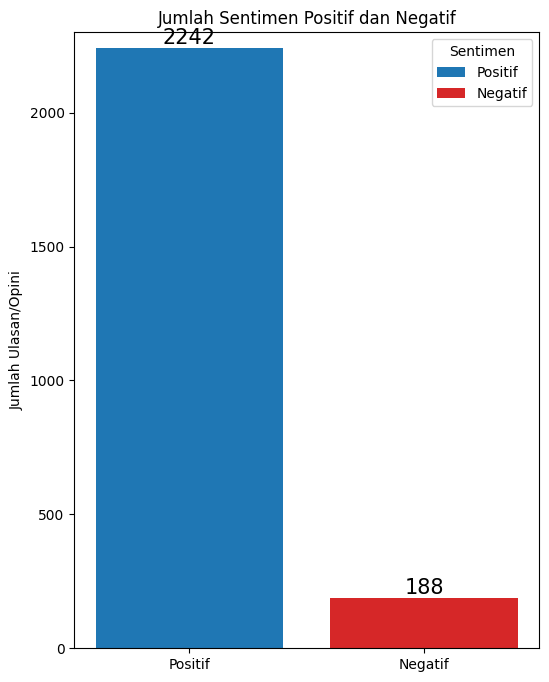

In [ ]:
fig, ax = plt.subplots(figsize=(6,8))
fruits = ['Positif', 'Negatif']
counts = [total_positif, total_negatif]
bar_labels = fruits
bar_colors = ['tab:blue', 'tab:red']
bar_container = ax.bar(fruits, counts, label=bar_labels, color=bar_colors)
ax.bar_label(bar_container, size = 15)
ax.set_ylim(0, 2300)
ax.set_ylabel('Jumlah Ulasan/Opini')
ax.set_title('Jumlah Sentimen Positif dan Negatif')
ax.legend(title='Sentimen')
plt.show()

**NLP (Natural Language Processing)**

WordCloud Sebelum Preperosesing

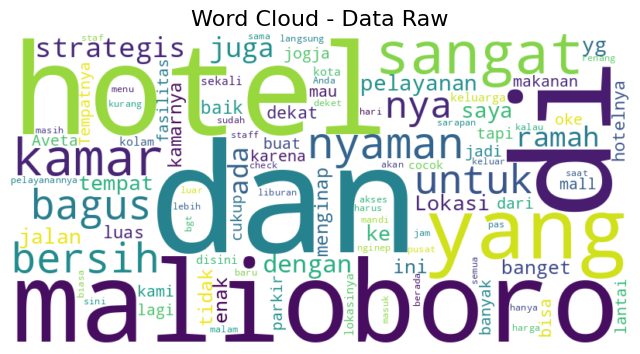

In [ ]:
# Visualisasi Word Cloud
text_all = " ".join(data['ulasan'])
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      max_words=100,
                      collocations=False).generate(text_all)
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Data Raw", fontsize=16)
plt.show()

# **PREPROSESING DATA**

**Case Folding dan Cleaning**

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() #casefolding

    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Hapus URL/link
    text = re.sub(r'@\w+', '', text) # Hapus mention @username
    text = re.sub(r'#', '', text) # Hapus hastag
    # Konversi rating bintang ke teks
    text = re.sub(r'bintang\s*1', ' bintang satu ', text, flags=re.IGNORECASE) # Jika terdapat bintang 1, dikonversi jadi kata bintang satu
    text = re.sub(r'bintang\s*2', ' bintang dua ', text, flags=re.IGNORECASE)
    text = re.sub(r'bintang\s*3', ' bintang tiga ', text, flags=re.IGNORECASE)
    text = re.sub(r'bintang\s*4', ' bintang empat ', text, flags=re.IGNORECASE)
    text = re.sub(r'bintang\s*5', ' bintang lima ', text, flags=re.IGNORECASE)
    # Cleaning umum
    text = re.sub(r'\d+', '', text) # Hapus angka
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Hapus tanda baca dan karakter non-huruf
    text = re.sub(r'(.)\1{1,}', r'\1', text)  # huruf berulang
    text = re.sub(r'\s+', ' ', text).strip() # Hapus spasi di awal/akhir
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.encode('ascii', 'ignore').decode('ascii')
    return text
    #apply to ulasan
data['cleaning'] = data['ulasan'].apply(clean_text)

print(data[['ulasan', 'cleaning']].head())

                                              ulasan  \
0  Hotel yang sgt strategis di jalan malioboro. K...   
1  Lokasi yang top. Di sekitar lokasi hotel banya...   
2  Kurang saya rekomendasikan. Pesan premier room...   
3  nginap 2 hari dan 2 malam bersama istri dan an...   
4  Saya memberikan bintang 2 ini sebelum saya mas...   

                                            cleaning  
0  hotel yang sgt strategis di jalan malioboro ka...  
1  lokasi yang top di sekitar lokasi hotel banyak...  
2  kurang saya rekomendasikan pesan premier rom d...  
3  nginap hari dan malam bersama istri dan ank sa...  
4  saya memberikan bintang dua ini sebelum saya m...  


**Tokenize**

In [ ]:
# def tokenize(text):
#     text = text.lower()
#     tokens = re.findall(r"[a-zA-Z0-9#@]+", text)
#     return tokens
# data['tokenize'] = data['cleaning'].apply(tokenize)
# print(data[['cleaning', 'tokenize']].head())

                                            cleaning  \
0  hotel yang sgt strategis di jalan malioboro ka...   
1  lokasi yang top di sekitar lokasi hotel banyak...   
2  kurang saya rekomendasikan pesan premier rom d...   
3  nginap hari dan malam bersama istri dan ank sa...   
4  saya memberikan bintang dua ini sebelum saya m...   

                                            tokenize  
0  [hotel, yang, sgt, strategis, di, jalan, malio...  
1  [lokasi, yang, top, di, sekitar, lokasi, hotel...  
2  [kurang, saya, rekomendasikan, pesan, premier,...  
3  [nginap, hari, dan, malam, bersama, istri, dan...  
4  [saya, memberikan, bintang, dua, ini, sebelum,...  


In [ ]:
from nltk.tokenize import word_tokenize
nltk.download('punkt')
# Fungsi pembungkus tokenisasi
def word_tokenize_wrapper(text):
    if isinstance(text, str):
        return word_tokenize(text)
    else:
        return []
# menerapkan fungsi tokenisasi pada kolom cleaning
data['tokenize'] = data['cleaning'].apply(word_tokenize_wrapper)

**Normalisasi**

In [ ]:
df_normal = pd.read_csv("normalisasi aveta.csv", sep=';')
df_normal

,kata,normalisasi
0,sgt,sangat
1,jg,juga
2,minusnya,kurang
3,house,rumah
4,keeping,penjaga
...,...,...
1524,lemar,lemari
1525,cil,kecil
1526,nginap,tinggal
1527,inap,tinggal


In [ ]:
dict_normal = {}
for awal_kata, normal in zip(df_normal['kata'], df_normal['normalisasi']):
  if awal_kata not in dict_normal:
    dict_normal[awal_kata] = normal

In [ ]:
dict_normal

{'sgt': 'sangat',
 'jg': 'juga',
 'minusnya': 'kurang',
 'house ': 'rumah',
 'keeping': 'penjaga',
 'ninggal': 'tinggal',
 'tdk': 'tidak',
 'mnrt': 'menurut',
 'sy': 'saya',
 'enak': 'lezat',
 'lbh': 'lebih',
 'lg': 'lagi',
 'dr': 'dari',
 'rekomended ': 'rekomendasi',
 'minimarket': 'toko kecil',
 'gak': 'tidak',
 'bf': 'sarapan pagi',
 'check inn': 'lapor masuk',
 'free': 'gratis',
 'esok': 'besok',
 'mo': 'ingin',
 'dlm': 'dalam',
 'list': 'daftar',
 'exclude': 'tidak masuk',
 'dgn': 'dengan',
 'nyala': 'hidup',
 'sekelas': 'setara',
 'amenities': 'perlengkapan',
 'yg': 'yang',
 'bener': 'tepat',
 'soo': 'jadi',
 'ae': 'aja',
 'icip': 'coba',
 'no': 'tidak',
 'komen': 'ulasan',
 'nginap': 'tinggal',
 'ank': 'anak',
 'pokoee': 'inti',
 'hrg': 'harga',
 'oke': 'setuju',
 'tidk': 'tidak',
 'tp': 'tapi',
 'krn': 'karena',
 'security': 'satuan pengamanan',
 'taroh': 'taruh',
 'tgl': 'tanggal',
 'booking': 'pesan',
 'wa': 'aplikasi pesan',
 'agak': 'sedikit',
 'defensif': 'bela',
 'early'

In [ ]:
normal

'wisata'

In [ ]:
def normalize_text(text):
    if not isinstance(text, list):
        return []
    return [
        dict_normal.get(word, word)
        for word in text
        if isinstance(word, str)
    ]
data['normalisasi'] = data['tokenize'].apply(normalize_text)
print(data[['tokenize', 'normalisasi']].head())

                                            tokenize  \
0  [hotel, yang, sgt, strategis, di, jalan, malio...   
1  [lokasi, yang, top, di, sekitar, lokasi, hotel...   
2  [kurang, saya, rekomendasikan, pesan, premier,...   
3  [nginap, hari, dan, malam, bersama, istri, dan...   
4  [saya, memberikan, bintang, dua, ini, sebelum,...   

                                         normalisasi  
0  [hotel, yang, sangat, mudah ditemukan, di, jal...  
1  [lokasi, yang, mantap, di, sekitar, lokasi, ho...  
2  [kurang, saya, rekomendasikan, pesan, premier,...  
3  [tinggal, hari, dan, malam, bersama, istri, da...  
4  [saya, memberikan, bintang, dua, ini, sebelum,...  


  Lemmazitation

In [ ]:
def stem_word(word):
    """Menghapus awalan dan akhiran umum Bahasa Indonesia secara sederhana"""
    prefixes = ['meng', 'meny', 'men', 'mem', 'me',
                'peng', 'peny', 'pen', 'pem', 'di', 'ke', 'se',
                'ber', 'ter', 'per', 're'] #awal
    suffixes = ['kan', 'an', 'i', 'lah', 'nya', 'ku', 'mu'] #akhir
    for p in prefixes:
        if word.startswith(p) and len(word) > len(p) + 2:
            word = word[len(p):]
            break
    for s in suffixes:
        if word.endswith(s) and len(word) > len(s) + 2:
            word = word[:-len(s)]
            break
    return word
def stem_sentence(sentence):
    return " ".join([stem_word(w) for w in sentence.split()])
data['lematisasi'] = data['normalisasi'].astype(str).apply(stem_sentence)
print(data[['normalisasi', 'lematisasi']].head())

                                         normalisasi  \
0  [hotel, yang, sangat, mudah ditemukan, di, jal...   
1  [lokasi, yang, mantap, di, sekitar, lokasi, ho...   
2  [kurang, saya, rekomendasikan, pesan, premier,...   
3  [tinggal, hari, dan, malam, bersama, istri, da...   
4  [saya, memberikan, bintang, dua, ini, sebelum,...   

                                          lematisasi  
0  ['hotel', 'yang', 'sangat', 'mudah temukan', '...  
1  ['lokasi', 'yang', 'mantap', 'di', 'sekitar', ...  
2  ['kurang', 'saya', 'rekomendasikan', 'pesan', ...  
3  ['tinggal', 'hari', 'dan', 'malam', 'bersama',...  
4  ['saya', 'memberikan', 'bintang', 'dua', 'ini'...  


**Stopword**

In [ ]:
df_stop = pd.read_csv("stopword aveta.csv")
df_stop

,stopword
0,hehehe
1,yah
2,nya
3,seh
4,dah
...,...
297,pun
298,cil
299,lemar
300,dl


In [ ]:
stopwords_custom = set(df_stop['stopword']) #stopword custom

In [ ]:
print(stopwords_custom)

{'atea', 'irwan', 'was', 'ke', 'heheh', 'toh ', 'beh', 'aaa', 'okay', 'dedy', 'tini', 'ehh', 'kok', 'to', 'c', 'dn', 'ter', 'lho', 'dehh', 'nyaa', 'yaaaa', 'tq', 'okeee', 'donk', 'or', 'silvi', 'gaes', 'dong', 'febby', 'nyaaa', 'rachel', 'per', 'lahhh', 'rachman', 'jacuzzi', 'nah', 'at', 'ny', 'anton', 'lux', 'cons', 'rara', 'tah', 'xixixixi', 'yaaa', 'ialah', 'hehehehe', 'xixixi', 'renata', 'waow', 'eki', 'si', 'eky ', 'al', 'ehhh', 'wow', 'rizel', 'heee', 'g', 'yaa', 'wil', 'rare', 'laaaa', 'mah', 'firdaus', 'danisa', 'ohya', 'e', 'alhamdulillah', 'pun', 'silvia', 'dl', 'astaga', 'ob', 'seh', 'lia', 'q', 'kel', 'it', 'haptic ', 'bud', 'koq', 'risa', 'aaahh', 'sii', 'dewanti', 'huhuhuhu', 'deh', 'so', 'luvv', 'nih', 'fan', 'hehehe', 'noval', 'ses', 'hemmm ', 'nanda', 'mey', 'feby', 'sih', 'huhu', 'kan', 'loh', 'wahyu', 'tisa', 'nya', 'isah', 'ya', 'dehhhh', 'oya', 'and', 'sese', 'isalia', 'hmm', 'a', 'ma', 'cherrssssss', 'ato ', 'ia', 'oh', 'oiyaa', 'yah', 'da', 'okee', 'kr', 'jom', '

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords_nltk = set(stopwords.words('indonesian'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
print(stopwords_nltk)

{'menyatakan', 'tegasnya', 'sekiranya', 'bung', 'ditunjuki', 'sempat', 'sebenarnya', 'dapat', 'menjadi', 'beginilah', 'sebisanya', 'kini', 'bersama', 'tempat', 'mempergunakan', 'ketika', 'seingat', 'lagi', 'belakang', 'akhiri', 'terutama', 'dipertanyakan', 'masa', 'semaunya', 'kepada', 'seenaknya', 'ditanya', 'sudahlah', 'sebagainya', 'berturut', 'kira', 'bermaksud', 'manalagi', 'nah', 'berikan', 'belum', 'tadinya', 'ditanyakan', 'meskipun', 'sajalah', 'sewaktu', 'siapapun', 'mungkinkah', 'terjadinya', 'jikalau', 'kembali', 'berujar', 'aku', 'bertanya-tanya', 'adanya', 'anda', 'serupa', 'dikatakannya', 'terjadi', 'amatlah', 'datang', 'berlainan', 'manakala', 'pun', 'bolehkah', 'dijawab', 'pada', 'kemungkinan', 'seolah', 'dimaksudkan', 'memberi', 'sebagian', 'itu', 'sedemikian', 'kemungkinannya', 'bukankah', 'sesudah', 'memang', 'akan', 'dengan', 'kira-kira', 'mempertanyakan', 'diketahui', 'mengucapkan', 'menunjuki', 'bagaimanapun', 'siap', 'mulailah', 'dimulai', 'mengerjakan', 'meyakin

In [ ]:
stopwords_combined = stopwords_nltk | stopwords_custom  #union stopwods

In [ ]:
stopwords_removal = {"tidak", "bukan", "jangan", "banyak",#List stopword yang dikurangi
                     "masalah", "penting", "waktu", "kurang",
                     "mau", "dijawab", "meminta", "tempat",
                     "dekat", "ingat", "gunkan", "besar", "bukan",
                     "kerja"
                   }

In [ ]:
stopwords_final = stopwords_combined - stopwords_removal #stopwords final

In [ ]:
print("Jumlah stopwords NLTK:", len(stopwords_nltk))
print("Stopwords custom:", len(stopwords_custom))
print("Stopword protected:",len(stopwords_removal))
print("Stopwords final:", len(stopwords_final))

Jumlah stopwords NLTK: 757
Stopwords custom: 194
Stopword protected: 17
Stopwords final: 921


In [ ]:
def token_list(x):
    # Jika nested list [[...]] → ambil dalamnya
    if isinstance(x, list) and len(x) == 1 and isinstance(x[0], list):
        x = x[0]
    # Jika masih string
    if isinstance(x, str):
        x = re.sub(r"[^a-zA-Z\s]", " ", x)
        return x.split()
    # Jika list → bersihkan tiap token
    clean_tokens = []
    for token in x:
        token = str(token).lower()
        token = re.sub(r"[^a-zA-Z]", "", token)
        if token.strip():
            clean_tokens.append(token)
    return clean_tokens
data['lematisasi'] = data['lematisasi'].apply(token_list)

In [ ]:
stopwords_final = set(w.strip().lower() for w in stopwords_final)

def remove_stopwords_list(tokens):
    return [w for w in tokens if w not in stopwords_final]

data['stopword'] = data['lematisasi'].apply(remove_stopwords_list)

In [ ]:
print(data[['lematisasi', 'stopword']].head())

                                          lematisasi  \
0  [hotel, yang, sangat, mudah, temukan, di, jala...   
1  [lokasi, yang, mantap, di, sekitar, lokasi, ho...   
2  [kurang, saya, rekomendasikan, pesan, premier,...   
3  [tinggal, hari, dan, malam, bersama, istri, da...   
4  [saya, memberikan, bintang, dua, ini, sebelum,...   

                                            stopword  
0  [hotel, mudah, temukan, jalan, malioboro, kary...  
1  [lokasi, mantap, lokasi, hotel, banyak, toko, ...  
2  [kurang, rekomendasikan, pesan, premier, kamar...  
3  [tinggal, malam, istri, anak, puas, nyaman, ba...  
4  [bintang, masuk, kamar, kamar, jam, tanggal, a...  


In [ ]:
i = 2
print("ASLI :", data['lematisasi'].iloc[i])
print("STOP :", data['stopword'].iloc[i])

ASLI : ['kurang', 'saya', 'rekomendasikan', 'pesan', 'premier', 'kamar', 'di', 'link', 'nya', 'aveta', 'hotel', 'tidak', 'dapat', 'sarap', 'pagi', 'padahal', 'waktu', 'check', 'masuk', 'dikabari', 'kita', 'fre', 'sarap', 'pagi', 'setelah', 'besok', 'hari', 'ingin', 'sarap', 'pagi', 'nomor', 'kamar', 'kita', 'tidak', 'ada', 'dalam', 'daftar', 'sarap', 'pagi', 'alias', 'tidak', 'masuk', 'sarap', 'pagi', 'kamar', 'cukup', 'bersih', 'dan', 'semua', 'berfungsi', 'dengan', 'baik', 'hanya', 'beberapa', 'kali', 'listrik', 'padam', 'sudah', 'konfirmasi', 'hidup', 'lagi', 'setara', 'hotel', 'bisa', 'mati', 'lampu', 'juga', 'perlengkapan', 'yang', 'ada', 'dikamar', 'kami', 'ada', 'salah', 'nya', 'sudah', 'dalam', 'keadan', 'setengah', 'terbuka', 'langsung', 'buang', 'yang', 'katanya', 'menghadap', 'malioboro', 'tepat', 'tapi', 'terhalang', 'pohon', 'dan', 'tembok', 'so', 'percuma', 'aja', 'seh', 'makan', 'minum', 'tidak', 'coba', 'jadi', 'tidak', 'ulasan']
STOP : ['kurang', 'rekomendasikan', 'pes

Stemming

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def remove_stopwords_list(token_list):
    if isinstance(token_list, list):
        return [word for word in token_list if word not in stopwords_final]
    return token_list
# Terapkan stemming
data['stemming'] = data['stopword'].apply(stem_list)

# Terapkan stopword ke kolom lemati
data['stopword'] = data['lematisasi'].apply(remove_stopwords_list)
def stem_list(tokens):
    return [stemmer.stem(w) for w in tokens]
# Terapkan stemming
data['stemming'] = data['stopword'].apply(stem_list)

data['compare'] = data.apply(
    lambda row: list(zip(row['stopword'], row['stemming'])),
    axis=1)

In [ ]:
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# factory = StemmerFactory()
# stemmer = factory.create_stemmer()
# def stem_text(tokens):
#     stemmed_tokens = [stemmer.stem(token) for token in tokens]
#     return stemmed_tokens
# df['stemming'] = df['stopword'].apply(stem_text)

In [ ]:
for i in [770]:
    row = data.loc[i]
    print(f"Data ke-{i}")
    for before, after in row['compare']:
        print(f"  {before} → {after}")

Data ke-770
  kamar → kamar
  mandi → mandi
  bersih → bersih
  air → air
  lancar → lancar
  kasur → kasur
  bersih → bersih
  lembut → lembut
  lokasi → lokasi
  pusat → pusat
  kota → kota
  karyawan → karyawan
  ramah → ramah
  tuhan → tuhan
  layanan → layan


In [ ]:
print(data[['stopword', 'stemming']].head())

                                            stopword  \
0  [hotel, mudah, temukan, jalan, malioboro, kary...   
1  [lokasi, mantap, lokasi, hotel, banyak, toko, ...   
2  [kurang, rekomendasikan, pesan, premier, kamar...   
3  [tinggal, malam, istri, anak, puas, nyaman, ba...   
4  [bintang, masuk, kamar, kamar, jam, tanggal, a...   

                                            stemming  
0  [hotel, mudah, temu, jalan, malioboro, karyawa...  
1  [lokasi, mantap, lokasi, hotel, banyak, toko, ...  
2  [kurang, rekomendasi, pesan, premier, kamar, l...  
3  [tinggal, malam, istri, anak, puas, nyaman, ba...  
4  [bintang, masuk, kamar, kamar, jam, tanggal, a...  


In [ ]:
i = 21
print("ASLI :", data['ulasan'].iloc[i])
print("STOP :", data['stemming'].iloc[i])

ASLI : Hotelnya bagus, nyaman. Lokasinya strategis mau jalan2 ke malioboro tinggal melangkah buka pintu, sangat rekomend deh...
STOP : ['hotel', 'bagus', 'nyaman', 'lokasi', 'mudah', 'temu', 'jalan', 'malioboro', 'tingal', 'lang', 'buka', 'pintu', 'rekomendasi']


**Wordcloud Data Cleand**

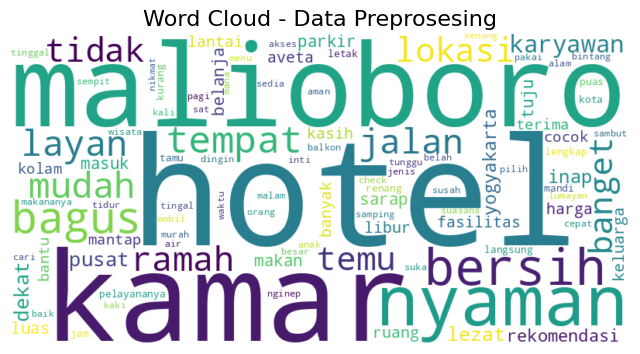

In [ ]:
#Visualisasi Word Cloud
text_all = " ".join(
    data['stemming'].apply(lambda x: " ".join(x))
)
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      max_words=100,
                      collocations=False).generate(text_all)
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Data Preprosesing", fontsize=16)
plt.show()

In [ ]:
data

,rating,ulasan,label,cleaning,tokenize,normalisasi,lematisasi,stopword,stemming,compare
0,5/5,Hotel yang sgt strategis di jalan malioboro. K...,Negatif,hotel yang sgt strategis di jalan malioboro ka...,"[hotel, yang, sgt, strategis, di, jalan, malio...","[hotel, yang, sangat, mudah ditemukan, di, jal...","[hotel, yang, sangat, mudah, temukan, di, jala...","[hotel, mudah, temukan, jalan, malioboro, kary...","[hotel, mudah, temu, jalan, malioboro, karyawa...","[(hotel, hotel), (mudah, mudah), (temukan, tem..."
1,5/5,Lokasi yang top. Di sekitar lokasi hotel banya...,Positif,lokasi yang top di sekitar lokasi hotel banyak...,"[lokasi, yang, top, di, sekitar, lokasi, hotel...","[lokasi, yang, mantap, di, sekitar, lokasi, ho...","[lokasi, yang, mantap, di, sekitar, lokasi, ho...","[lokasi, mantap, lokasi, hotel, banyak, toko, ...","[lokasi, mantap, lokasi, hotel, banyak, toko, ...","[(lokasi, lokasi), (mantap, mantap), (lokasi, ..."
2,2/5,Kurang saya rekomendasikan. Pesan premier room...,Negatif,kurang saya rekomendasikan pesan premier rom d...,"[kurang, saya, rekomendasikan, pesan, premier,...","[kurang, saya, rekomendasikan, pesan, premier,...","[kurang, saya, rekomendasikan, pesan, premier,...","[kurang, rekomendasikan, pesan, premier, kamar...","[kurang, rekomendasi, pesan, premier, kamar, l...","[(kurang, kurang), (rekomendasikan, rekomendas..."
3,5/5,nginap 2 hari dan 2 malam bersama istri dan an...,Positif,nginap hari dan malam bersama istri dan ank sa...,"[nginap, hari, dan, malam, bersama, istri, dan...","[tinggal, hari, dan, malam, bersama, istri, da...","[tinggal, hari, dan, malam, bersama, istri, da...","[tinggal, malam, istri, anak, puas, nyaman, ba...","[tinggal, malam, istri, anak, puas, nyaman, ba...","[(tinggal, tinggal), (malam, malam), (istri, i..."
4,2/5,Saya memberikan bintang 2 ini sebelum saya mas...,Negatif,saya memberikan bintang dua ini sebelum saya m...,"[saya, memberikan, bintang, dua, ini, sebelum,...","[saya, memberikan, bintang, dua, ini, sebelum,...","[saya, memberikan, bintang, dua, ini, sebelum,...","[bintang, masuk, kamar, kamar, jam, tanggal, a...","[bintang, masuk, kamar, kamar, jam, tanggal, a...","[(bintang, bintang), (masuk, masuk), (kamar, k..."
...,...,...,...,...,...,...,...,...,...,...
2425,5/5,Semoga beruntung 👍🏻,Positif,semoga beruntung,"[semoga, beruntung]","[semoga, beruntung]","[semoga, beruntung]","[semoga, beruntung]","[moga, untung]","[(semoga, moga), (beruntung, untung)]"
2426,4/5,Playanan 👍👍👍,Positif,playanan,[playanan],[playanan],[playanan],[playanan],[playanan],"[(playanan, playanan)]"
2427,1/5,Manyalah..,Negatif,manyalah,[manyalah],[menyala],[menyala],[menyala],[nyala],"[(menyala, nyala)]"
2428,5/5,Daerah Malioboro,Positif,daerah malioboro,"[daerah, malioboro]","[daerah, malioboro]","[daerah, malioboro]","[daerah, malioboro]","[daerah, malioboro]","[(daerah, daerah), (malioboro, malioboro)]"


In [ ]:
persen_nan = data['stemming'].isna().mean() * 100
print(f"Missing value kolom stemming: {persen_nan:.2f}%")

Missing value kolom stemming: 0.00%


In [ ]:
data_empty = data[
    (data['lematisasi'].apply(lambda x: len(x)==0)) |
    (data['stopword'].apply(lambda x: len(x)==0)) |
    (data['stemming'].apply(lambda x: len(x)==0))
]
print("Baris Bermasalah")
print(data_empty.head())
print("Minimal panjang lematisasi :", data['lematisasi'].apply(len).min())
print("Minimal panjang stopword   :", data['stopword'].apply(len).min())
print("Minimal panjang stemming:", data['stemming'].apply(len).min())

Baris Bermasalah
     rating          ulasan    label        cleaning            tokenize  \
2112    5/5   semuanya baik  Positif   semuanya baik    [semuanya, baik]   
2168    5/5           👍👍👍👍👍  Positif                                  []   
2170    3/5  Baik-baik saja  Positif  baik baik saja  [baik, baik, saja]   
2219    5/5      luar biasa  Positif      luar biasa       [luar, biasa]   
2271    5/5     Luar biasa!  Positif      luar biasa       [luar, biasa]   

             normalisasi          lematisasi stopword stemming compare  
2112    [semuanya, baik]    [semuanya, baik]       []       []      []  
2168                  []                  []       []       []      []  
2170  [baik, baik, saja]  [baik, baik, saja]       []       []      []  
2219       [luar, biasa]       [luar, biasa]       []       []      []  
2271       [luar, biasa]       [luar, biasa]       []       []      []  
Minimal panjang lematisasi : 0
Minimal panjang stopword   : 0
Minimal panjang stemming: 

In [ ]:
persen = (len(data_empty) / len(data)) * 100
print(f"Persentase data bermasalah: {persen:.2f}%")

Persentase data bermasalah: 0.25%


In [ ]:
print("Index data bermasalah:")
print(data_empty.index.tolist())

Index data bermasalah:
[2112, 2168, 2170, 2219, 2271, 2296]


In [ ]:
data = data[data['stemming'].apply(lambda x: len(x) > 0)].reset_index(drop=True)

In [ ]:
print("Total data awal :", len(data))
print("Total data akhir:", len(data))
print("Data di-drop    :", len(data) - len(data))

Total data awal : 2424
Total data akhir: 2424
Data di-drop    : 0


**Wordcloud Kata Positif dan Negatif**

In [ ]:
df_pos = data[data['label'] == 'Positif']
df_neg = data[data['label'] == 'Negatif']

Kata Positif

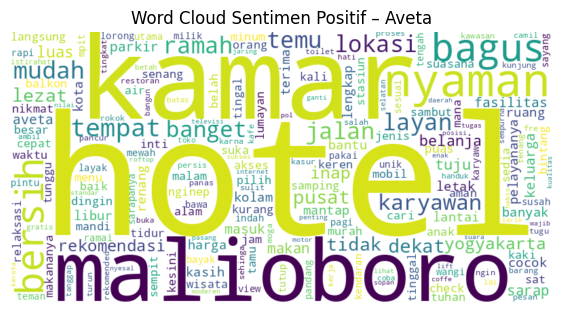

In [ ]:
text_pos = " ".join(
    [" ".join(tokens) for tokens in df_pos['stemming']]
)
wc_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False
).generate(text_pos)
plt.figure(figsize=(7, 4))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Sentimen Positif – Aveta")
plt.show()

**Kata Negatif**

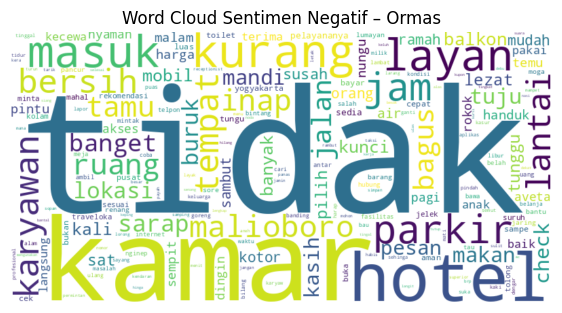

In [ ]:
text_pos = " ".join(
    [" ".join(tokens) for tokens in df_neg['stemming']]
)
wc_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False
).generate(text_pos)
plt.figure(figsize=(7, 4))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Sentimen Negatif – Ormas")
plt.show()

In [ ]:
# Melihat kembali baris yang telah di tokenisasi
for i, tokens in enumerate(data['stemming']):
    print(f"Review {i+1}:")
    print(tokens, "\n")

Review 1:
['hotel', 'mudah', 'temu', 'jalan', 'malioboro', 'karyawan', 'ramah', 'kamar', 'bersih', 'bersih', 'keping', 'bersih', 'cepat', 'kerja', 'kurang', 'tidak', 'lahan', 'parkir', 'batas', 'tugas', 'parkir', 'ningal', 'kunci', 'tidak', 'nyaman', 'kamar', 'mandi', 'tidak', 'hand', 'pancur', 'bawa', 'baby', 'susah', 'mandi', 'pancur', 'atap', 'sarap', 'variasi', 'lumayan', 'kurang', 'tidak', 'lezat', 'lezat', 'moga', 'tingkat', 'kamar', 'tidak', 'kedap', 'tarik', 'kursi', 'kamar', 'belah', 'moga', 'baik', 'hotel', 'rekomended', 'coba', 'moga', 'layan', 'kebersihanya', 'jaga'] 

Review 2:
['lokasi', 'mantap', 'lokasi', 'hotel', 'banyak', 'toko', 'toko', 'jual', 'barang', 'toko', 'ruang', 'jenis', 'kamar', 'luas', 'bersih', 'harum', 'sedia', 'dispenser', 'air', 'minum', 'kamar', 'jenis', 'keluarga', 'kamar', 'tidak', 'susah', 'susah', 'beli', 'air', 'minum'] 

Review 3:
['kurang', 'rekomendasi', 'pesan', 'premier', 'kamar', 'link', 'aveta', 'hotel', 'tidak', 'sarap', 'pagi', 'waktu', 

In [ ]:
data['jumlah_kata'] = data['stemming'].apply(len)

In [ ]:
data[['stemming', 'jumlah_kata']].head()

,stemming,jumlah_kata
0,"[hotel, mudah, temu, jalan, malioboro, karyawa...",61
1,"[lokasi, mantap, lokasi, hotel, banyak, toko, ...",30
2,"[kurang, rekomendasi, pesan, premier, kamar, l...",63
3,"[tinggal, malam, istri, anak, puas, nyaman, ba...",38
4,"[bintang, masuk, kamar, kamar, jam, tanggal, a...",61


In [ ]:
print(data['jumlah_kata'].describe())

count    2424.000000
mean       12.999587
std        17.066124
min         1.000000
25%         4.000000
50%         8.000000
75%        15.000000
max       210.000000
Name: jumlah_kata, dtype: float64


In [ ]:
print("Minimal :", data['jumlah_kata'].min())
print("Maksimal:", data['jumlah_kata'].max())
print("Rata-rata:", data['jumlah_kata'].mean())

Minimal : 1
Maksimal: 210
Rata-rata: 12.999587458745875


In [ ]:
data= data[
    ~(
        (data['label'] == 'Positif') &
        (data['jumlah_kata'] < 10)
    )
].reset_index(drop=True)

In [ ]:
print("Sebelum drop:")
print(data['label'].value_counts())

print("\nSesudah drop:")
print(data['label'].value_counts())

Sebelum drop:
label
Positif    915
Negatif    188
Name: count, dtype: int64

Sesudah drop:
label
Positif    915
Negatif    188
Name: count, dtype: int64


In [ ]:
print("Jumlah data di-drop:",
      len(data) - len(data))

Jumlah data di-drop: 0


In [ ]:
# # Simpan hasil teks preprosesing
# data.to_csv("hasil_preprosesing.csv", index=False, encoding='utf-8-sig')

# TF-IDF FRECUENCY

In [ ]:
df = pd.read_csv('hasil_preprosesing_aveta.csv')
print(f"Total data: {len(df)}")
df.head()

Total data: 1103


,rating,ulasan,label,cleaning,tokenize,normalisasi,lematisasi,stopword,stemming,compare,jumlah_kata
0,5/5,Hotel yang sgt strategis di jalan malioboro. K...,Negatif,hotel yang sgt strategis di jalan malioboro ka...,"['hotel', 'yang', 'sgt', 'strategis', 'di', 'j...","['hotel', 'yang', 'sangat', 'mudah ditemukan',...","['hotel', 'yang', 'sangat', 'mudah', 'temukan'...","['hotel', 'mudah', 'temukan', 'jalan', 'maliob...","['hotel', 'mudah', 'temu', 'jalan', 'malioboro...","[('hotel', 'hotel'), ('mudah', 'mudah'), ('tem...",61
1,5/5,Lokasi yang top. Di sekitar lokasi hotel banya...,Positif,lokasi yang top di sekitar lokasi hotel banyak...,"['lokasi', 'yang', 'top', 'di', 'sekitar', 'lo...","['lokasi', 'yang', 'mantap', 'di', 'sekitar', ...","['lokasi', 'yang', 'mantap', 'di', 'sekitar', ...","['lokasi', 'mantap', 'lokasi', 'hotel', 'banya...","['lokasi', 'mantap', 'lokasi', 'hotel', 'banya...","[('lokasi', 'lokasi'), ('mantap', 'mantap'), (...",30
2,2/5,Kurang saya rekomendasikan. Pesan premier room...,Negatif,kurang saya rekomendasikan pesan premier rom d...,"['kurang', 'saya', 'rekomendasikan', 'pesan', ...","['kurang', 'saya', 'rekomendasikan', 'pesan', ...","['kurang', 'saya', 'rekomendasikan', 'pesan', ...","['kurang', 'rekomendasikan', 'pesan', 'premier...","['kurang', 'rekomendasi', 'pesan', 'premier', ...","[('kurang', 'kurang'), ('rekomendasikan', 'rek...",63
3,5/5,nginap 2 hari dan 2 malam bersama istri dan an...,Positif,nginap hari dan malam bersama istri dan ank sa...,"['nginap', 'hari', 'dan', 'malam', 'bersama', ...","['tinggal', 'hari', 'dan', 'malam', 'bersama',...","['tinggal', 'hari', 'dan', 'malam', 'bersama',...","['tinggal', 'malam', 'istri', 'anak', 'puas', ...","['tinggal', 'malam', 'istri', 'anak', 'puas', ...","[('tinggal', 'tinggal'), ('malam', 'malam'), (...",38
4,2/5,Saya memberikan bintang 2 ini sebelum saya mas...,Negatif,saya memberikan bintang dua ini sebelum saya m...,"['saya', 'memberikan', 'bintang', 'dua', 'ini'...","['saya', 'memberikan', 'bintang', 'dua', 'ini'...","['saya', 'memberikan', 'bintang', 'dua', 'ini'...","['bintang', 'masuk', 'kamar', 'kamar', 'jam', ...","['bintang', 'masuk', 'kamar', 'kamar', 'jam', ...","[('bintang', 'bintang'), ('masuk', 'masuk'), (...",61


In [6]:
# Melihat kembali baris yang telah di tokenisasi
for i, tokens in enumerate(df['stemming']):
    print(f"Review {i+1}:")
    print(tokens, "\n")

Review 1:
['hotel', 'mudah', 'temu', 'jalan', 'malioboro', 'karyawan', 'ramah', 'kamar', 'bersih', 'bersih', 'keping', 'bersih', 'cepat', 'kerja', 'kurang', 'tidak', 'lahan', 'parkir', 'batas', 'tugas', 'parkir', 'ningal', 'kunci', 'tidak', 'nyaman', 'kamar', 'mandi', 'tidak', 'hand', 'pancur', 'bawa', 'baby', 'susah', 'mandi', 'pancur', 'atap', 'sarap', 'variasi', 'lumayan', 'kurang', 'tidak', 'lezat', 'lezat', 'moga', 'tingkat', 'kamar', 'tidak', 'kedap', 'tarik', 'kursi', 'kamar', 'belah', 'moga', 'baik', 'hotel', 'rekomended', 'coba', 'moga', 'layan', 'kebersihanya', 'jaga'] 

Review 2:
['lokasi', 'mantap', 'lokasi', 'hotel', 'banyak', 'toko', 'toko', 'jual', 'barang', 'toko', 'ruang', 'jenis', 'kamar', 'luas', 'bersih', 'harum', 'sedia', 'dispenser', 'air', 'minum', 'kamar', 'jenis', 'keluarga', 'kamar', 'tidak', 'susah', 'susah', 'beli', 'air', 'minum'] 

Review 3:
['kurang', 'rekomendasi', 'pesan', 'premier', 'kamar', 'link', 'aveta', 'hotel', 'tidak', 'sarap', 'pagi', 'waktu', 

In [11]:
df['stemming'] = df['stemming'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [12]:
index = 0
for i in df['stemming']:
  if index == 5:
    break
  print(type(i))
  index += 1

<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


**Perhitungan TF**

In [13]:
def calc_TF(document):
    # Step 1: Count term occurrences
    tf_dict = {}
    for term in document:
        if term in tf_dict:
            tf_dict[term] += 1
        else:
            tf_dict[term] = 1

    # Step 2: Normalize by the total number of terms (TF calculation)
    for term in tf_dict:
        tf_dict[term] = tf_dict[term] / len(document)

    return tf_dict

# Apply TF calculation to each list of tokens in 'tekslist'
df["tf"] = df["stemming"].apply(calc_TF)

# Display the first few TF dictionaries
df["tf"].head()

,tf
0,"{'hotel': 0.03278688524590164, 'mudah': 0.0163..."
1,"{'lokasi': 0.06666666666666667, 'mantap': 0.03..."
2,"{'kurang': 0.015873015873015872, 'rekomendasi'..."
3,"{'tinggal': 0.02631578947368421, 'malam': 0.02..."
4,"{'bintang': 0.01639344262295082, 'masuk': 0.06..."


In [14]:
#Displaying a Document’s TF Values
#Prints all terms and their Term Frequency (TF) values for a specific document (here, document index = 1)
index = 0

print("%20s" % "term", "\t", "tf\n")
for key in df["tf"][index]:
    print('%20s' % key, "\t", df["tf"][index][key])

                term 	 tf

               hotel 	 0.03278688524590164
               mudah 	 0.01639344262295082
                temu 	 0.01639344262295082
               jalan 	 0.01639344262295082
           malioboro 	 0.01639344262295082
            karyawan 	 0.01639344262295082
               ramah 	 0.01639344262295082
               kamar 	 0.06557377049180328
              bersih 	 0.04918032786885246
              keping 	 0.01639344262295082
               cepat 	 0.01639344262295082
               kerja 	 0.01639344262295082
              kurang 	 0.03278688524590164
               tidak 	 0.08196721311475409
               lahan 	 0.01639344262295082
              parkir 	 0.03278688524590164
               batas 	 0.01639344262295082
               tugas 	 0.01639344262295082
              ningal 	 0.01639344262295082
               kunci 	 0.01639344262295082
              nyaman 	 0.01639344262295082
               mandi 	 0.03278688524590164
                hand 	 0.01

**Perhitungan IDF**

In [15]:
#Calculating Document Frequency (DF)
def calc_DF(tfDict):
    count_DF = {}
    for document in tfDict:
        for term in document:
            if term in count_DF:
                count_DF[term] += 1
            else:
                count_DF[term] = 1
    return count_DF

DF = calc_DF(df["tf"])
DF

{'hotel': 626,
 'mudah': 393,
 'temu': 363,
 'jalan': 332,
 'malioboro': 521,
 'karyawan': 273,
 'ramah': 314,
 'kamar': 580,
 'bersih': 407,
 'keping': 6,
 'cepat': 80,
 'kerja': 18,
 'kurang': 107,
 'tidak': 276,
 'lahan': 10,
 'parkir': 137,
 'batas': 20,
 'tugas': 19,
 'ningal': 1,
 'kunci': 17,
 'nyaman': 320,
 'mandi': 95,
 'hand': 1,
 'pancur': 25,
 'bawa': 39,
 'baby': 1,
 'susah': 44,
 'atap': 8,
 'sarap': 180,
 'variasi': 15,
 'lumayan': 52,
 'lezat': 213,
 'moga': 24,
 'tingkat': 23,
 'kedap': 12,
 'tarik': 13,
 'kursi': 14,
 'belah': 80,
 'baik': 56,
 'rekomended': 17,
 'coba': 23,
 'layan': 304,
 'kebersihanya': 5,
 'jaga': 10,
 'lokasi': 360,
 'mantap': 59,
 'banyak': 139,
 'toko': 19,
 'jual': 13,
 'barang': 23,
 'ruang': 125,
 'jenis': 47,
 'luas': 189,
 'harum': 8,
 'sedia': 55,
 'dispenser': 5,
 'air': 56,
 'minum': 39,
 'keluarga': 107,
 'beli': 8,
 'rekomendasi': 140,
 'pesan': 32,
 'premier': 3,
 'link': 1,
 'aveta': 140,
 'pagi': 41,
 'waktu': 47,
 'check': 70,
 '

In [16]:
#Calculating Inverse Document Frequency (IDF)
n_document = len(df)

def calc_IDF(n_document, DF):
    IDF_dict = {}
    for term in DF:
        IDF_dict[term] = np.log10(n_document / (DF[term] + 1))
    return IDF_dict

IDF = calc_IDF(n_document, DF)

In [17]:
selected_terms = ['aveta', 'nyaman', 'malioboro']

idf_selected = {term: IDF.get(term, 0) for term in selected_terms}
print("Nilai IDF untuk kata ['aveta', 'nyaman', 'malioboro']:")
print(idf_selected)

Nilai IDF untuk kata ['aveta', 'nyaman', 'malioboro']:
{'aveta': np.float64(0.8933563997848106), 'nyaman': np.float64(0.5360704800353185), 'malioboro': np.float64(0.32490500943792844)}


In [18]:
#Calculating TF-IDF
#Purpose:
#Computes the TF-IDF value for each term in each document by multiplying TF and IDF.
def calc_TF_IDF(TF, IDF):
    TF_IDF_dict = {}
    for key in TF:
        if key in IDF:  # add safety check
            TF_IDF_dict[key] = TF[key] * IDF[key]
    return TF_IDF_dict

# Apply properly
df["tf-idf"] = df["tf"].apply(lambda x: calc_TF_IDF(x, IDF))

**Hasil perhitungan TF_IDF**

In [19]:
# Tampilkan nilai TF dan TF-IDF untuk dokumen ke-1
index = 1

print(f'{"Term":<20}\t{"TF":<10}\t{"TF-IDF":<20}')
print('-' * 60)

for term, tfidf_val in df["tf-idf"][index].items():
    tf_val = df["tf"][index].get(term, 0)
    print(f'{term:<20}\t{tf_val:<10.4f}\t{tfidf_val:<20.6f}')

Term                	TF        	TF-IDF              
------------------------------------------------------------
lokasi              	0.0667    	0.032338            
mantap              	0.0333    	0.042147            
hotel               	0.0333    	0.008177            
banyak              	0.0333    	0.029882            
toko                	0.1000    	0.174155            
jual                	0.0333    	0.063215            
barang              	0.0333    	0.055412            
ruang               	0.0333    	0.031407            
jenis               	0.0667    	0.090756            
kamar               	0.1000    	0.027840            
luas                	0.0333    	0.025461            
bersih              	0.0333    	0.014397            
harum               	0.0333    	0.069611            
sedia               	0.0333    	0.043146            
dispenser           	0.0333    	0.075481            
air                 	0.0667    	0.085780            
minum               	0.0667    	0.0960

**Matrik TF-IDF Vectorizer**

In [20]:
# Membuat matriks TF-IDF
# Urutkan kata berdasarkan Document Frequency (descending)
sorted_DF = sorted(DF.items(), key=lambda kv: kv[1], reverse=True)[:30]
unique_terms = [term for term, _ in sorted_DF]

# Fungsi untuk mengonversi TF-IDF dict ke vektor
def calc_TF_IDF_Vec(tfidf_dict):
    vector = [0.0] * len(unique_terms)
    for i, term in enumerate(unique_terms):
        vector[i] = tfidf_dict.get(term, 0.0)
    return vector

# Terapkan fungsi ke setiap dokumen
df["tf_idf_vectoring"] = df["tf-idf"].apply(calc_TF_IDF_Vec)

# Cek hasil
print("Tampilan baris pertama dari matriks tf_idf_vectoring:\n")
print(df["tf_idf_vectoring"].iloc[1])
print("\nUkuran vektor (jumlah fitur):", len(df["tf_idf_vectoring"].iloc[0]))

Tampilan baris pertama dari matriks tf_idf_vectoring:

[np.float64(0.008176932386982472), np.float64(0.027839938004985992), 0.0, np.float64(0.014397178311677023), 0.0, 0.0, np.float64(0.032337887368968844), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.02000319144585807), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.025460730382912054), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(0.029881582558731752), 0.0]

Ukuran vektor (jumlah fitur): 30


**Menampilkan hasil ke dalam List**

In [22]:
# Menampilkan top 30 term berdasarkan total TF-IDF
# Konversi kolom TF-IDF vector menjadi array 2D
TF_IDF_Vec_List = np.array(df["tf_idf_vectoring"].to_list())

# Hitung jumlah TF-IDF setiap term di seluruh dokumen
term_sums = TF_IDF_Vec_List.sum(axis=0)

# Buat DataFrame untuk peringkat term
ranking = pd.DataFrame({
    'Term': unique_terms,
    'TF-IDF': term_sums
})
# Urutkan dari nilai tertinggi ke terendah
ranking = ranking.sort_values(by='TF-IDF', ascending=False).reset_index(drop=True)

# Tampilkan top 30 term
print("Top 30 terms berdasarkan total TF-IDF:")
print(ranking.head(100))

Top 30 terms berdasarkan total TF-IDF:
           Term     TF-IDF
0         tidak  12.581542
1        banget  11.993531
2         hotel  11.939635
3         bagus  11.920150
4         layan  11.837971
5        tempat  11.538017
6        nyaman  11.381477
7        bersih  11.347515
8         kamar  11.230191
9     malioboro  11.012952
10     karyawan  10.849279
11        ramah  10.746338
12        mudah  10.656715
13        jalan  10.427847
14         temu  10.099575
15       lokasi   9.864570
16       parkir   9.608220
17        dekat   9.271968
18        lezat   8.911763
19        pusat   8.808065
20   yogyakarta   8.220045
21         inap   7.576423
22  rekomendasi   7.111467
23         luas   6.963548
24      belanja   6.616483
25        masuk   6.565454
26        makan   6.511164
27        aveta   6.469732
28        sarap   6.247512
29       banyak   5.156932


In [23]:
#Analisis kata penting per dokumen
for i, tfidf_vector in enumerate(TF_IDF_Vec_List[:10]):  # contoh 5 dokumen pertama
    top_indices = tfidf_vector.argsort()[-5:][::-1]  # ambil 5 term tertinggi
    top_terms = [unique_terms[idx] for idx in top_indices]
    print(f"Dokumen {i}: {top_terms}")

Dokumen 0: ['tidak', 'parkir', 'lezat', 'bersih', 'kamar']
Dokumen 1: ['lokasi', 'banyak', 'kamar', 'luas', 'tidak']
Dokumen 2: ['sarap', 'tidak', 'masuk', 'kamar', 'rekomendasi']
Dokumen 3: ['parkir', 'banget', 'lezat', 'tidak', 'bagus']
Dokumen 4: ['masuk', 'kamar', 'banyak', 'aveta', 'rekomendasi']
Dokumen 5: ['banget', 'masuk', 'bersih', 'banyak', 'makan']
Dokumen 6: ['inap', 'layan', 'kamar', 'rekomendasi', 'aveta']
Dokumen 7: ['makan', 'tidak', 'layan', 'ramah', 'lokasi']
Dokumen 8: ['inap', 'rekomendasi', 'luas', 'karyawan', 'tempat']
Dokumen 9: ['banget', 'karyawan', 'banyak', 'ramah', 'sarap']


In [24]:
dict_label_sentimen = {}
label_classes = []
index = 0
for label in data['label']:
  if label not in dict_label_sentimen:
    dict_label_sentimen[label] = index
    label_classes.append(label)
    index += 1

In [25]:
data['encoded'] = data['label'].apply(lambda x: dict_label_sentimen[x])

In [26]:
dict_label_sentimen

{'Negatif': 0, 'Positif': 1}

In [ ]:
# df.to_csv("aveta_final.csv", index = False)

# **Klasifikasi Model**

In [ ]:
data = pd.read_csv('final_aveta.csv')
print(f"Total data: {len(data)}")
data.head()

Total data: 1103


,rating,ulasan,label,cleaning,tokenize,normalisasi,lematisasi,stopword,stemming,compare,jumlah_kata,tf,tf-idf,tf_idf_vectoring,encoded
0,5/5,Hotel yang sgt strategis di jalan malioboro. K...,Negatif,hotel yang sgt strategis di jalan malioboro ka...,"['hotel', 'yang', 'sgt', 'strategis', 'di', 'j...","['hotel', 'yang', 'sangat', 'mudah ditemukan',...","['hotel', 'yang', 'sangat', 'mudah', 'temukan'...","['hotel', 'mudah', 'temukan', 'jalan', 'maliob...","['hotel', 'mudah', 'temu', 'jalan', 'malioboro...","[('hotel', 'hotel'), ('mudah', 'mudah'), ('tem...",61,"{'hotel': 0.03278688524590164, 'mudah': 0.0163...","{'hotel': np.float64(0.008042884315064726), 'm...","[np.float64(0.008042884315064726), np.float64(...",0
1,5/5,Lokasi yang top. Di sekitar lokasi hotel banya...,Positif,lokasi yang top di sekitar lokasi hotel banyak...,"['lokasi', 'yang', 'top', 'di', 'sekitar', 'lo...","['lokasi', 'yang', 'mantap', 'di', 'sekitar', ...","['lokasi', 'yang', 'mantap', 'di', 'sekitar', ...","['lokasi', 'mantap', 'lokasi', 'hotel', 'banya...","['lokasi', 'mantap', 'lokasi', 'hotel', 'banya...","[('lokasi', 'lokasi'), ('mantap', 'mantap'), (...",30,"{'lokasi': 0.06666666666666667, 'mantap': 0.03...","{'lokasi': np.float64(0.032337887368968844), '...","[np.float64(0.008176932386982472), np.float64(...",1
2,2/5,Kurang saya rekomendasikan. Pesan premier room...,Negatif,kurang saya rekomendasikan pesan premier rom d...,"['kurang', 'saya', 'rekomendasikan', 'pesan', ...","['kurang', 'saya', 'rekomendasikan', 'pesan', ...","['kurang', 'saya', 'rekomendasikan', 'pesan', ...","['kurang', 'rekomendasikan', 'pesan', 'premier...","['kurang', 'rekomendasi', 'pesan', 'premier', ...","[('kurang', 'kurang'), ('rekomendasikan', 'rek...",63,"{'kurang': 0.015873015873015872, 'rekomendasi'...","{'kurang': np.float64(0.016018281856400647), '...","[np.float64(0.00778755465426902), np.float64(0...",0
3,5/5,nginap 2 hari dan 2 malam bersama istri dan an...,Positif,nginap hari dan malam bersama istri dan ank sa...,"['nginap', 'hari', 'dan', 'malam', 'bersama', ...","['tinggal', 'hari', 'dan', 'malam', 'bersama',...","['tinggal', 'hari', 'dan', 'malam', 'bersama',...","['tinggal', 'malam', 'istri', 'anak', 'puas', ...","['tinggal', 'malam', 'istri', 'anak', 'puas', ...","[('tinggal', 'tinggal'), ('malam', 'malam'), (...",38,"{'tinggal': 0.02631578947368421, 'malam': 0.02...","{'tinggal': np.float64(0.03681902199878955), '...","[0.0, np.float64(0.007326299474996314), 0.0, 0...",1
4,2/5,Saya memberikan bintang 2 ini sebelum saya mas...,Negatif,saya memberikan bintang dua ini sebelum saya m...,"['saya', 'memberikan', 'bintang', 'dua', 'ini'...","['saya', 'memberikan', 'bintang', 'dua', 'ini'...","['saya', 'memberikan', 'bintang', 'dua', 'ini'...","['bintang', 'masuk', 'kamar', 'kamar', 'jam', ...","['bintang', 'masuk', 'kamar', 'kamar', 'jam', ...","[('bintang', 'bintang'), ('masuk', 'masuk'), (...",61,"{'bintang': 0.01639344262295082, 'masuk': 0.06...","{'bintang': np.float64(0.021093453389634413), ...","[0.0, np.float64(0.01825569705244983), 0.0, 0....",0


In [28]:
total_negatif = len(data[data['label'] == "Negatif"])
total_positif = len(data[data['label'] == "Positif"])

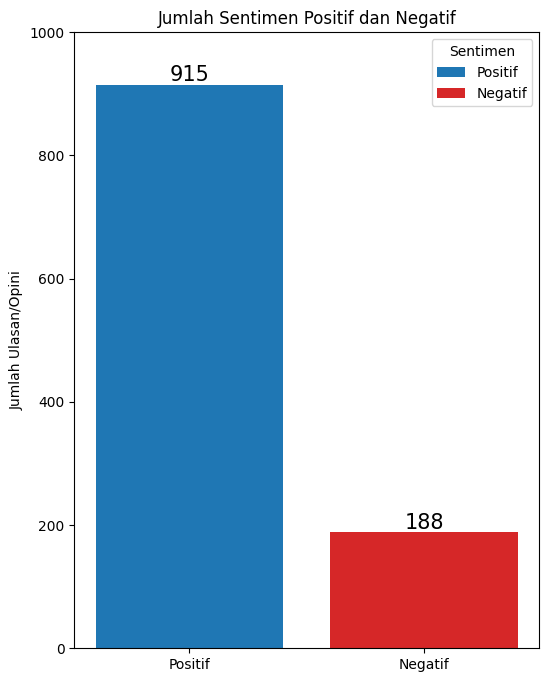

In [29]:
fig, ax = plt.subplots(figsize=(6,8))
fruits = ['Positif', 'Negatif']
counts = [total_positif, total_negatif]
bar_labels = fruits
bar_colors = ['tab:blue', 'tab:red']
bar_container = ax.bar(fruits, counts, label=bar_labels, color=bar_colors)
ax.bar_label(bar_container, size = 15)
ax.set_ylim(0, 1000)
ax.set_ylabel('Jumlah Ulasan/Opini')
ax.set_title('Jumlah Sentimen Positif dan Negatif')
ax.legend(title='Sentimen')
plt.show()

Split Data

In [51]:
import ast
def safe_eval(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []
data['stemming'] = data['stemming'].apply(safe_eval)

In [52]:
X = data['stemming']
y = data['encoded']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X

,stemming
0,"[hotel, mudah, temu, jalan, malioboro, karyawa..."
1,"[lokasi, mantap, lokasi, hotel, banyak, toko, ..."
2,"[kurang, rekomendasi, pesan, premier, kamar, l..."
3,"[tinggal, malam, istri, anak, puas, nyaman, ba..."
4,"[bintang, masuk, kamar, kamar, jam, tanggal, a..."
...,...
1098,"[kamar, besar, tempat, bagus, orang, sarapanya..."
1099,[tidak]
1100,"[alam, jelek]"
1101,[nongkrong]


In [54]:
sentiment_counts = {
    'Positif': np.array([0, 0]),
    'Negatif': np.array([0, 0])
}

In [55]:
for label in y_train:
  sentiment_counts[label_classes[label]][0] += 1

for label in y_test:
  sentiment_counts[label_classes[label]][1] += 1

In [56]:
sentiment_counts[label_classes[label]]

array([727, 188])

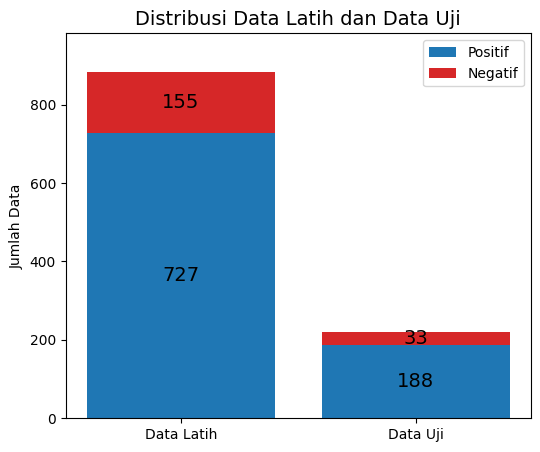

In [57]:
fig, ax = plt.subplots(figsize=(6, 5))
bottom = np.zeros(2)
data_horizontal = ('Data Latih', 'Data Uji')
bar_colors = {
    'Positif': 'tab:blue',
    'Negatif': 'tab:red'
}
for label in ['Positif', 'Negatif']:
    jumlah_sentimen = sentiment_counts[label]
    p = ax.bar(
        data_horizontal,
        jumlah_sentimen,
        bottom=bottom,
        label=label,
        color=bar_colors[label],
        width=0.8
    )
    ax.bar_label(
        p,
        labels=[f"{v:.0f}" for v in jumlah_sentimen],
        label_type='center',
        color='black',
        size=14
    )
    bottom += jumlah_sentimen
ax.set_title('Distribusi Data Latih dan Data Uji', fontsize=14)
ax.set_ylabel('Jumlah Data')
ax.legend()
ax.set_ylim(0, bottom.max() + 100)
plt.show()

# Ekstrasi Fitur (TF-IDF)

In [ ]:
# tfidf = TfidfVectorizer(
#     tokenizer=lambda x: x,
#     preprocessor=lambda x: x,
#     token_pattern=None
# )
tfidf = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 1),
    max_df=0.9,
    min_df=2,
    sublinear_tf=True,
    norm='l2'
)
# # Fit dan transform data training
# X_train = tfidf.fit_transform(X_train)
# # Transform data testing (tanpa fit ulang)
# X_test = tfidf.transform(X_test)

In [59]:
tfidf.fit(X_train)

TfidfVectorizer(preprocessor=<function <lambda> at 0x7afcd0da9ee0>,
                token_pattern=None,
                tokenizer=<function <lambda> at 0x7afcd0da84a0>)

In [60]:
tfidf.idf_

array([6.39703084, 7.09017802, 5.48074011, ..., 7.09017802, 7.09017802,
       7.09017802])

In [61]:
tfidf.get_feature_names_out()[:20]

array(['abis', 'about', 'acara', 'aceh', 'aces', 'ada', 'adakan', 'adan',
       'adlh', 'admin', 'aduh', 'aduk', 'afordable', 'agam', 'agama',
       'agoda', 'ah', 'ahirnya', 'air', 'aja'], dtype=object)

In [62]:
tfidf.vocabulary_

{'buruk': 266,
 'hotel': 603,
 'bagus': 109,
 'tempat': 1840,
 'mudah': 1140,
 'temu': 1841,
 'dekat': 366,
 'banget': 137,
 'stasiun': 1726,
 'tugu': 1920,
 'tingal': 1876,
 'jalan': 661,
 'kaki': 712,
 'nikmat': 1192,
 'suguh': 1748,
 'jajan': 657,
 'pingir': 1362,
 'jala': 660,
 'malam': 1017,
 'kuliner': 891,
 'suasana': 1744,
 'yogyakarta': 2020,
 'takut': 1789,
 'karyawan': 734,
 'aveta': 100,
 'ramah': 1431,
 'ruang': 1514,
 'bersih': 201,
 'tidur': 1870,
 'kamar': 719,
 'mandi': 1043,
 'air': 18,
 'panas': 1264,
 'lancar': 919,
 'parkir': 1279,
 'luas': 995,
 'dalam': 350,
 'libur': 968,
 'belah': 180,
 'pusat': 1420,
 'belanja': 181,
 'malioboro': 1027,
 'sukses': 1753,
 'trus': 1913,
 'lokasi': 989,
 'nyaman': 1213,
 'layan': 940,
 'harga': 577,
 'lumayan': 1000,
 'tingi': 1878,
 'kurang': 903,
 'rekomendasi': 1465,
 'pesan': 1348,
 'premier': 1393,
 'link': 977,
 'tidak': 1869,
 'sarap': 1568,
 'pagi': 1252,
 'waktu': 1987,
 'check': 308,
 'masuk': 1061,
 'kabar': 699,
 'fre

In [63]:
print(len(tfidf.vocabulary_))

2028


In [64]:
X_train = tfidf.transform(X_train)
X_test = tfidf.transform(X_test)

# Naive Bayes

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 10, 1000]
}

grid = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=5,
    scoring='f1_macro'
)

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=MultinomialNB(),
             param_grid={'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 10, 1000]},
             scoring='f1_macro')

In [ ]:
nbm = grid.best_estimator_

In [ ]:
print("Alpha terbaik:", grid.best_params_)
print("Score terbaik:", grid.best_score_)
print("Best estimator:", grid.best_estimator_)

Alpha terbaik: {'alpha': 0.01}
Score terbaik: 0.7611475937688715
Best estimator: MultinomialNB(alpha=0.01)


Testing

TRAINING EVALUATION
Accuracy (Train): 0.9761904761904762

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.99      0.87      0.93       155
           1       0.97      1.00      0.99       727

    accuracy                           0.98       882
   macro avg       0.98      0.93      0.96       882
weighted avg       0.98      0.98      0.98       882



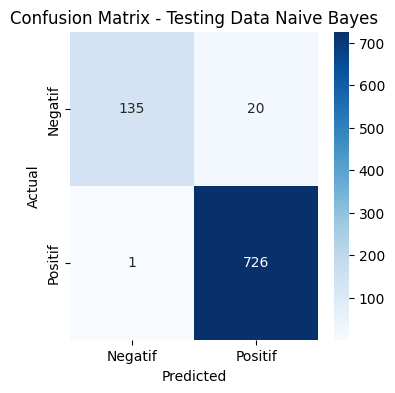

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, hinge_loss
# Prediksi data testing
print("TRAINING EVALUATION")
y_pred = nbm.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)

print("Accuracy (Train):", train_acc)
print("\nClassification Report (Train):")
print(classification_report(y_train, y_pred))
#confusing matrix
cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data Naive Bayes")
plt.show()

Training

TESTING EVALUATION (NAIVE BAYES)
Accuracy  : 0.8914
Precision : 0.8815
Recall    : 0.8914
F1-Score  : 0.8831
Log Loss  : 0.2644

Classification Report (Test):
              precision    recall  f1-score   support

     Negatif       0.70      0.48      0.57        33
     Positif       0.91      0.96      0.94       188

    accuracy                           0.89       221
   macro avg       0.80      0.72      0.75       221
weighted avg       0.88      0.89      0.88       221



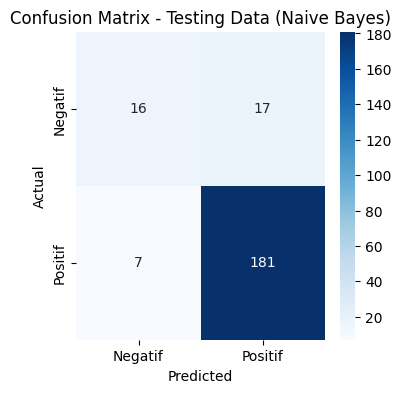

In [ ]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,log_loss)
# Prediksi
y_pred = nbm.predict(X_test)
y_proba = nbm.predict_proba(X_test)
# Evaluasi
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')
loss = log_loss(y_test, y_proba)

print("TESTING EVALUATION (NAIVE BAYES)")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"Log Loss  : {loss:.4f}")
print("\nClassification Report (Test):")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negatif", "Positif"]
))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (Naive Bayes)")
plt.show()

# Suport Vector Machine (SVM)

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC

param_grid = {
    "C": [0.01, 0.05, 0.1, 0.5, 1, 2]
}

svm = LinearSVC(
    class_weight="balanced",
    max_iter=15000,
    random_state=42,
    dual=False
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(class_weight='balanced', dual=False,
                                 max_iter=15000, random_state=42),
             n_jobs=-1, param_grid={'C': [0.01, 0.05, 0.1, 0.5, 1, 2]},
             scoring='f1_macro')

In [ ]:
svm = grid.best_estimator_

In [ ]:
print("Best C:", grid.best_params_)
print("Best CV F1_macro:", grid.best_score_)
print("Best estimator:", grid.best_estimator_)

Best C: {'C': 1}
Best CV F1_macro: 0.8635158909952553
Best estimator: LinearSVC(C=1, class_weight='balanced', dual=False, max_iter=15000,
          random_state=42)


Training

TRAINING EVALUATION
Accuracy (Train): 0.9977324263038548
Hinge Loss (Train): 0.13158006070320816

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       155
           1       1.00      1.00      1.00       727

    accuracy                           1.00       882
   macro avg       0.99      1.00      1.00       882
weighted avg       1.00      1.00      1.00       882



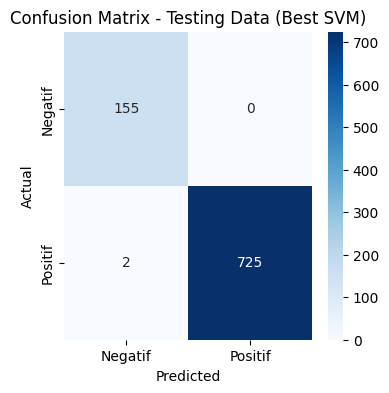

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, hinge_loss
# Prediksi data testing
print("TRAINING EVALUATION")

y_pred = svm.predict(X_train)
y_score = svm.decision_function(X_train)

train_acc = accuracy_score(y_train, y_pred)
train_loss = hinge_loss(y_train, y_score)

print("Accuracy (Train):", train_acc)
print("Hinge Loss (Train):", train_loss)
print("\nClassification Report (Train):")
print(classification_report(y_train, y_pred))
#confusing matrix
cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (Best SVM)")
plt.show()

Testing

TESTING EVALUATION (SVM)
Accuracy   : 0.9140
Precision  : 0.9151
Recall     : 0.9140
F1-Score   : 0.9146
Hinge Loss : 0.2997

Classification Report (Test):
              precision    recall  f1-score   support

     Negatif       0.71      0.73      0.72        33
     Positif       0.95      0.95      0.95       188

    accuracy                           0.91       221
   macro avg       0.83      0.84      0.83       221
weighted avg       0.92      0.91      0.91       221



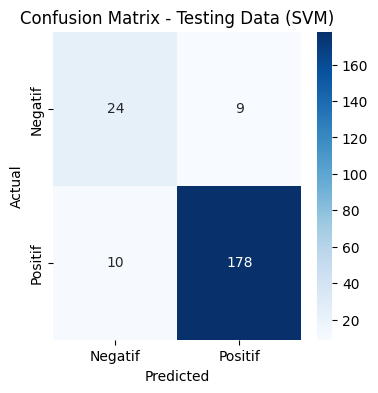

In [ ]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,hinge_loss)

print("TESTING EVALUATION (SVM)")
y_pred = svm.predict(X_test)
y_score = svm.decision_function(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
loss = hinge_loss(y_test, y_score)

print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1-Score   : {f1:.4f}")
print(f"Hinge Loss : {loss:.4f}")

print("\nClassification Report (Test):")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negatif", "Positif"]
))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (SVM)")
plt.show()